<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P4/Tugas_E1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E1 NO.1


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def test_histogram_methods(image_path):
    img = cv.imread('/content/drive/MyDrive/PCVK_2026/lena.jpg')
    if img is None:
        print(f"Error: Gambar tidak ditemukan di {image_path}")
        return

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    height, width, _ = img_rgb.shape

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK_2026/lena.jpg')
if img is None:
    print("Error: Gambar tidak ditemukan. Pastikan path sudah benar.")
else:
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    height, width, _ = img_rgb.shape

    red_manual = [0] * 256
    green_manual = [0] * 256
    blue_manual = [0] * 256
    for y in range(height):
        for x in range(width):
            red_manual[img_rgb[y][x][0]] += 1
            green_manual[img_rgb[y][x][1]] += 1
            blue_manual[img_rgb[y][x][2]] += 1

    manual_hist = np.array([red_manual, green_manual, blue_manual])
    print("Perhitungan histogram manual berhasil dilakukan!")

Perhitungan histogram manual berhasil dilakukan!


In [ ]:
# Metode NumPy
numpy_hist = []
for c in range(3):
    h, _ = np.histogram(img_rgb[:, :, c], bins=256, range=(0, 256))
    numpy_hist.append(h)
numpy_hist = np.array(numpy_hist)
print("Perhitungan histogram NumPy berhasil dilakukan!")

Perhitungan histogram NumPy berhasil dilakukan!


In [ ]:
# Metode OpenCV
opencv_hist = []
for c in range(3):
    h = cv.calcHist([img_rgb], [c], None, [256], [0, 256])
    opencv_hist.append(h.flatten())
opencv_hist = np.array(opencv_hist, dtype=np.int64)
print("Perhitungan histogram OpenCV berhasil dilakukan!")

Perhitungan histogram OpenCV berhasil dilakukan!


In [ ]:
# Menghitung selisih maksimum
diff_manual_numpy = np.max(np.abs(manual_hist - numpy_hist))
diff_manual_opencv = np.max(np.abs(manual_hist - opencv_hist))
diff_numpy_opencv = np.max(np.abs(numpy_hist - opencv_hist))

print("=== HASIL PENGUJIAN ===")
print(f"Selisih Maksimum (Manual vs NumPy)  : {diff_manual_numpy}")
print(f"Selisih Maksimum (Manual vs OpenCV) : {diff_manual_opencv}")
print(f"Selisih Maksimum (NumPy vs OpenCV)  : {diff_numpy_opencv}")

if diff_manual_numpy == 0 and diff_manual_opencv == 0 and diff_numpy_opencv == 0:
    print(">>> PEMBUKTIAN BERHASIL: Selisih antar ketiga metode adalah 0! <<<\n")
else:
    print(">>> Terdapat perbedaan hasil! <<<\n")

=== HASIL PENGUJIAN ===
Selisih Maksimum (Manual vs NumPy)  : 0
Selisih Maksimum (Manual vs OpenCV) : 0
Selisih Maksimum (NumPy vs OpenCV)  : 0
>>> PEMBUKTIAN BERHASIL: Selisih antar ketiga metode adalah 0! <<<



# E1 No.2

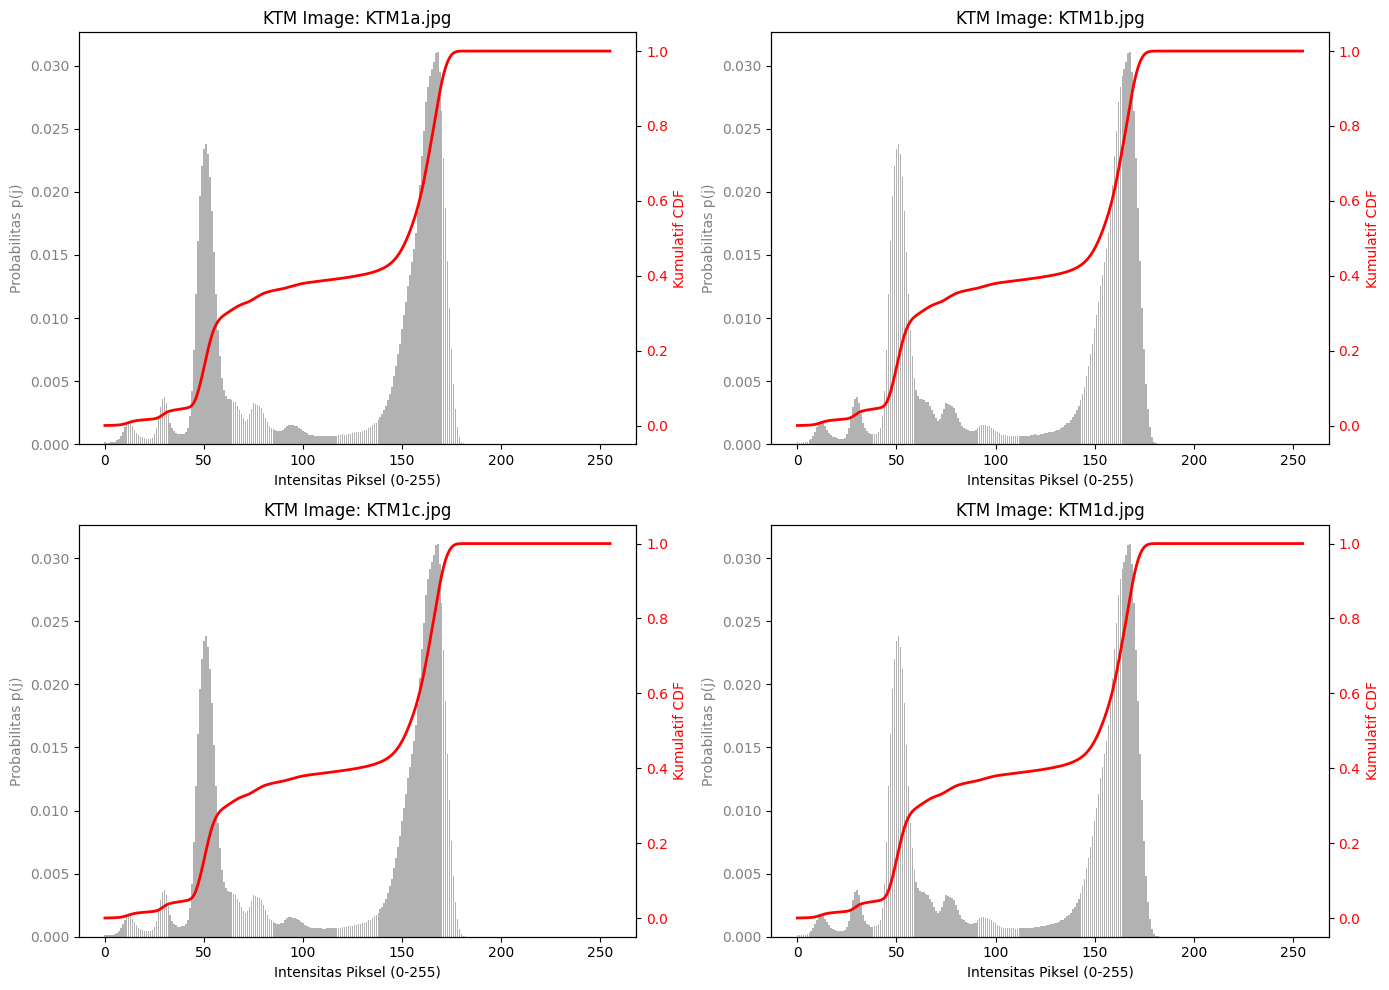

In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

images = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
base_path = '/content/drive/MyDrive/PCVK_2026/'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, img_name in enumerate(images):
    img = cv.imread(base_path + img_name, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Gambar {img_name} tidak ditemukan di {base_path}")
        continue

    # 1. Menghitung histogram dan normalisasi
    hist, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    p_j = hist / hist.sum()
    cdf = p_j.cumsum()

    # 2. Plotting Histogram
    ax1 = axes[i]
    ax1.bar(range(256), p_j, color='gray', alpha=0.6, label='Histogram p(j)')
    ax1.set_xlabel('Intensitas Piksel (0-255)')
    ax1.set_ylabel('Probabilitas p(j)', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')

    # 3. Plotting CDF (Sumbu Y sebelah kanan)
    ax2 = ax1.twinx()
    ax2.plot(range(256), cdf, color='red', linewidth=2, label='Kurva CDF')
    ax2.set_ylabel('Kumulatif CDF', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.set_title(f'KTM Image: {img_name}')

plt.tight_layout()
plt.show()

In [15]:
# menghitung histogram dan normalisasi
hist, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
p_j = hist / hist.sum()

cdf = p_j.cumsum()

In [17]:
ax1 = axes[i]
ax1.bar(range(256), p_j, color='gray', alpha=0.6, label='Histogram p(j)')
ax1.set_xlabel('Intensitas Piksel (0-255)')
ax1.set_ylabel('Probabilitas p(j)', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

In [20]:
ax2 = ax1.twinx()
ax2.plot(range(256), cdf, color='red', linewidth=2, label='Kurva CDF')
ax2.set_ylabel('Kumulatif CDF', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title(f'KTM Image: {img_name}')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

E1 NO.3


In [22]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {'bins': 16} # Anda bisa mengganti nilainya misal 16, 32, atau 64

img_path = '/content/drive/MyDrive/PCVK_2026/KTM1b.jpg'
img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

if img is not None:
    plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

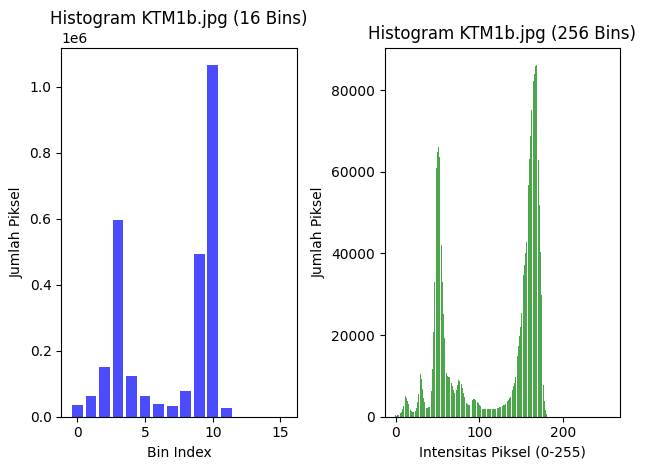

In [23]:
    plt.subplot(1, 2, 1)
    hist_custom, bin_edges_custom = np.histogram(img.flatten(), bins=PARAM['bins'], range=[0, 256])
    plt.bar(range(PARAM['bins']), hist_custom, color='blue', alpha=0.7)
    plt.title(f"Histogram KTM1b.jpg ({PARAM['bins']} Bins)")
    plt.xlabel('Bin Index')
    plt.ylabel('Jumlah Piksel')

    plt.subplot(1, 2, 2)
    hist_256, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    plt.bar(range(256), hist_256, color='green', alpha=0.7)
    plt.title('Histogram KTM1b.jpg (256 Bins)')
    plt.xlabel('Intensitas Piksel (0-255)')
    plt.ylabel('Jumlah Piksel')

    plt.tight_layout()
    plt.show()